In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load our data
df = pd.read_csv('../data/raw/reviews_with_sentiment.csv')

print(f"Loaded {len(df)} reviews")
print(df.columns.tolist())

Loaded 1478 reviews
['review', 'rating', 'date', 'bank', 'source', 'sentiment_label', 'sentiment_score']


<Figure size 1200x500 with 0 Axes>

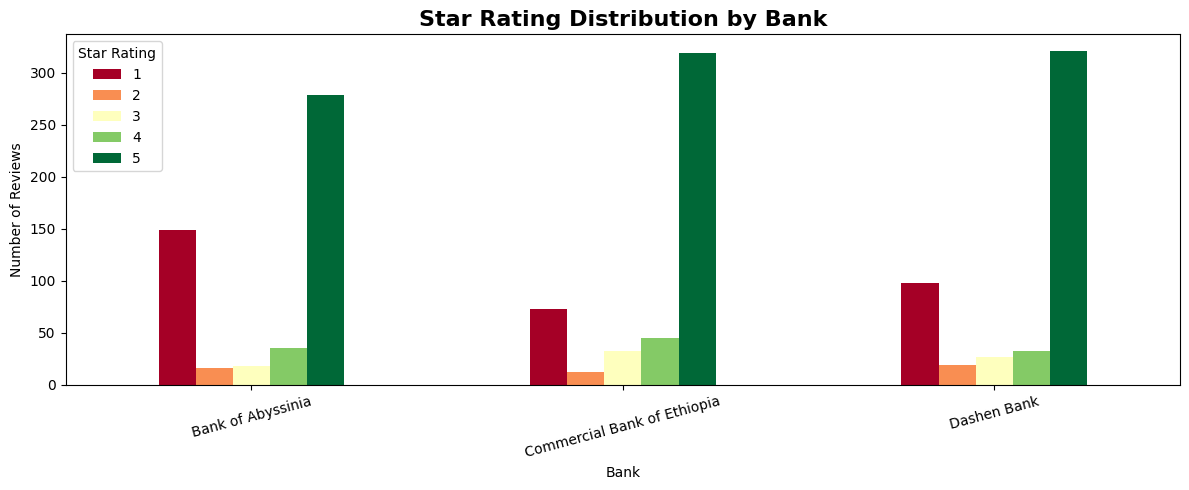

Chart saved!


In [2]:
plt.figure(figsize=(12, 5))

# Count how many reviews have each star rating per bank
rating_dist = df.groupby(['bank', 'rating']).size().unstack(fill_value=0)

rating_dist.plot(
    kind='bar',
    figsize=(12, 5),
    colormap='RdYlGn'
)

plt.title('Star Rating Distribution by Bank', fontsize=16, fontweight='bold')
plt.xlabel('Bank')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=15)
plt.legend(title='Star Rating')
plt.tight_layout()
plt.savefig('../data/raw/rating_distribution.png', dpi=150)
plt.show()
print("Chart saved!")

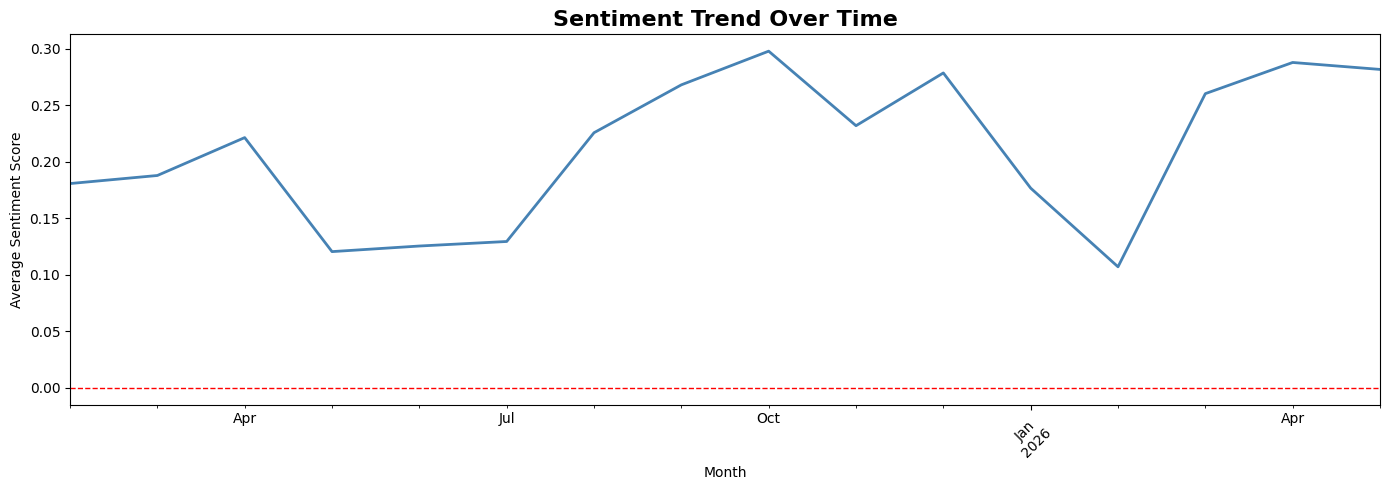

 Chart saved!


In [4]:
# Convert date to datetime
df['date'] = pd.to_datetime(df['date'])

# Get month and year from date
df['month'] = df['date'].dt.to_period('M')

# Calculate average sentiment score per month
sentiment_trend = df.groupby('month')['sentiment_score'].mean()

plt.figure(figsize=(14, 5))
sentiment_trend.plot(kind='line', color='steelblue', linewidth=2)

plt.title('Sentiment Trend Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Average Sentiment Score')
plt.xticks(rotation=45)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
plt.tight_layout()
plt.savefig('../data/raw/sentiment_trend.png', dpi=150)
plt.show()
print(" Chart saved!")

Themes assigned!


<Figure size 1400x600 with 0 Axes>

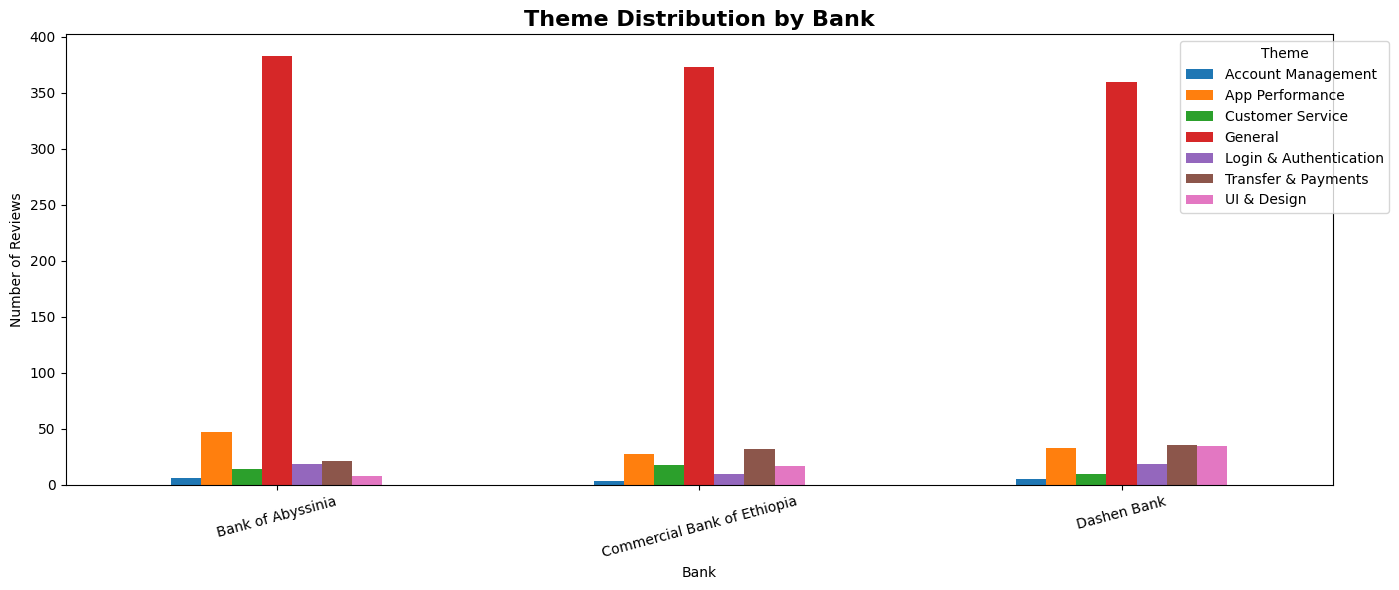

Chart saved!


In [7]:
import sys
sys.path.append('..')

# Check if theme column exists
if 'theme' not in df.columns:
    from src.themes import assign_theme
    df['theme'] = df['review'].apply(assign_theme)
    print("Themes assigned!")
else:
    print("Theme column already exists!")

plt.figure(figsize=(14, 6))
theme_dist = df.groupby(['bank', 'theme']).size().unstack(fill_value=0)

theme_dist.plot(
    kind='bar',
    figsize=(14, 6)
)

plt.title('Theme Distribution by Bank', fontsize=16, fontweight='bold')
plt.xlabel('Bank')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=15)
plt.legend(title='Theme', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig('../data/raw/theme_distribution.png', dpi=150)
plt.show()
print("Chart saved!")

In [8]:
print("=" * 60)
print("KEY INSIGHTS SUMMARY")
print("=" * 60)

for bank in df['bank'].unique():
    bank_df = df[df['bank'] == bank]
    
    total = len(bank_df)
    positive = len(bank_df[bank_df['sentiment_label'] == 'positive'])
    negative = len(bank_df[bank_df['sentiment_label'] == 'negative'])
    neutral = len(bank_df[bank_df['sentiment_label'] == 'neutral'])
    avg_rating = bank_df['rating'].mean()
    avg_sentiment = bank_df['sentiment_score'].mean()
    top_theme = bank_df['theme'].value_counts().index[0] if 'theme' in bank_df.columns else 'N/A'
    
    print(f"\n{bank}")
    print(f"   Total Reviews:     {total}")
    print(f"   Average Rating:    {avg_rating:.2f} / 5.0")
    print(f"   Avg Sentiment:     {avg_sentiment:.3f}")
    print(f"   Positive:          {positive} ({positive/total*100:.1f}%)")
    print(f"   Neutral:           {neutral} ({neutral/total*100:.1f}%)")
    print(f"   Negative:          {negative} ({negative/total*100:.1f}%)")
    print(f"   Top Theme:         {top_theme}")
    print("-" * 40)

KEY INSIGHTS SUMMARY

Commercial Bank of Ethiopia
   Total Reviews:     482
   Average Rating:    4.09 / 5.0
   Avg Sentiment:     0.282
   Positive:          321 (66.6%)
   Neutral:           110 (22.8%)
   Negative:          51 (10.6%)
   Top Theme:         General
----------------------------------------

Bank of Abyssinia
   Total Reviews:     498
   Average Rating:    3.56 / 5.0
   Avg Sentiment:     0.182
   Positive:          264 (53.0%)
   Neutral:           144 (28.9%)
   Negative:          90 (18.1%)
   Top Theme:         General
----------------------------------------

Dashen Bank
   Total Reviews:     498
   Average Rating:    3.92 / 5.0
   Avg Sentiment:     0.293
   Positive:          319 (64.1%)
   Neutral:           111 (22.3%)
   Negative:          68 (13.7%)
   Top Theme:         General
----------------------------------------
